# Latent Capacity Sweep

Systematically train latent simulators while varying latent dimensionality, number of training networks, and number of training frames per trajectory. The summary focuses on first-frame p-ratio readout and decoded latent rollout p-ratio performance.


In [45]:
from __future__ import annotations

import math
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import Tensor
from torch_geometric.data import Data
from torch_geometric.utils import to_dense_batch

from graph_utils import calc_p_ratio_rollout_sides, draw_graph, pyg_to_networkx, remove_periodic_edges
from course_project.data import load_dataset, resolve_dataset_splits
from course_project.graph import clone_graph
from course_project.utils import resolve_device

plt.rcParams['figure.dpi'] = 120



In [ ]:
seed = random.SystemRandom().randrange(1, 2**31)
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)
print('run seed:', seed)

# Sweep controls. Increase these after a smoke run.
latent_dims = [1, 2, 3]
train_counts = [1, 2, 4, 8]
train_frame_counts = [2, 5, 10, 25, 50, 100]

cfg = {
    'dataset_path': '../data/new_reid_combined.pt',
    'val_count': 25,
    'latent_tokens': 12,
    'hidden_size': 128,
    'edge_feature_dim': 16,
    'pos_dim': 2,
    'batch_graphs': 8,
    'frame_skip': 10,
    'ae_max_epochs': 35,
    'ae_patience': 15,
    'ae_lr': 1e-3,
    'ae_weight_decay': 1e-5,
    'dyn_max_epochs': 35,
    'dyn_patience': 15,
    'dyn_lr': 1e-3,
    'dyn_weight_decay': 1e-5,
    'early_stop_min_delta': 1e-5,
    'rollout_steps_grid': [80],  # use [10, 20, 40, 80] for a full rollout curve
    'summary_rollout_step': 80,
    'sweep_eval_splits': ['test'],
    'eval_max_sims_per_split': None,  # set e.g. 40 for faster smoke runs
    'keep_trained_models': False,
    'checkpoint_each_run': True,
    'resume_completed_sweep': False,
    'node_feature_mode': 'delta',
    'split_seed': seed,
    'shuffle_dataset_within_source': True,
    'device': 'auto',
    'output_root': 'results/latent_space_capacity_sweep',
}


def resolve_existing_path(path_like):
    path = Path(path_like)
    if path.exists():
        return str(path)
    if str(path).startswith('../'):
        repo_relative_path = Path(str(path)[3:])
        if repo_relative_path.exists():
            return str(repo_relative_path)
    return str(path)

cfg['dataset_path'] = resolve_existing_path(cfg['dataset_path'])
device = resolve_device(cfg['device'])
run_dir = Path(cfg['output_root'])
run_dir.mkdir(parents=True, exist_ok=True)
print('device:', device)
print('output:', run_dir)
pd.DataFrame([cfg])



In [47]:
def filtered_frame_ids(sim, *, include_last=False, max_frames=None):
    stop = len(sim) if include_last else len(sim) - 1
    step = max(1, int(cfg.get('frame_skip', 1)))
    frame_ids = list(range(0, max(stop, 0), step))
    if max_frames is not None:
        frame_ids = frame_ids[:int(max_frames)]
    return [int(t) for t in frame_ids]


def frame_for_filtered_step(sim, filtered_step):
    frame_ids = filtered_frame_ids(sim, include_last=True, max_frames=None)
    if not frame_ids:
        return 0
    idx = min(int(filtered_step), len(frame_ids) - 1)
    return int(frame_ids[idx])


def make_frame_index(sims, *, max_frames_per_sim=None, include_last=False):
    rows = []
    for sim_idx, sim in enumerate(sims):
        frame_ids = filtered_frame_ids(sim, include_last=include_last, max_frames=max_frames_per_sim)
        rows.extend((sim_idx, int(t)) for t in frame_ids)
    return rows


def make_transition_index(sims, *, max_frames_per_sim=None):
    rows = []
    for sim_idx, sim in enumerate(sims):
        frame_ids = filtered_frame_ids(sim, include_last=True, max_frames=None)
        pairs = list(zip(frame_ids[:-1], frame_ids[1:]))
        if max_frames_per_sim is not None:
            pairs = pairs[:int(max_frames_per_sim)]
        rows.extend((sim_idx, int(t0), int(t1)) for t0, t1 in pairs)
    return rows


def iter_batches(rows, batch_graphs, *, shuffle=True):
    rows = list(rows)
    if shuffle:
        random.shuffle(rows)
    for i in range(0, len(rows), int(batch_graphs)):
        yield rows[i:i + int(batch_graphs)]


def edge_features(ref_graph, cur_graph, *, device):
    ref_e = ref_graph.edge_attr.to(device).float()
    cur_e = cur_graph.edge_attr.to(device).float()
    ref_vec = ref_e[:, :cfg['pos_dim']]
    cur_vec = cur_e[:, :cfg['pos_dim']]
    ref_len = ref_e[:, cfg['pos_dim']:cfg['pos_dim'] + 1]
    cur_len = cur_e[:, cfg['pos_dim']:cfg['pos_dim'] + 1]
    stiffness = ref_e[:, -1:]
    stretch = cur_len - ref_len
    rel_stretch = stretch / ref_len.clamp_min(1e-6)
    return torch.cat([ref_vec, cur_vec, ref_len, cur_len, stretch, rel_stretch, stiffness, cur_e], dim=-1)


def frame_node_feature(sim, t, *, mode, device):
    t = int(t)
    cur_pos = sim[t].x[:, :cfg['pos_dim']].to(device).float()
    if mode in ('position', 'positions'):
        return cur_pos
    if mode == 'delta':
        ref_pos = sim[0].x[:, :cfg['pos_dim']].to(device).float()
        return cur_pos - ref_pos
    if mode == 'velocity':
        if t <= 0:
            return torch.zeros_like(cur_pos)
        prev_pos = sim[t - 1].x[:, :cfg['pos_dim']].to(device).float()
        return cur_pos - prev_pos
    raise ValueError(f'Unknown node_feature_mode: {mode}')


def batch_delta_graphs(sims, rows, *, device, node_feature_mode='delta'):
    xs = []
    node_features = []
    ref_xs = []
    edge_attrs = []
    ref_edge_attrs = []
    edge_indices = []
    batch = []
    node_offset = 0
    for local_idx, (sim_idx, t) in enumerate(rows):
        sim = sims[int(sim_idx)]
        ref_graph = sim[0]
        cur_graph = sim[int(t)]
        ref_pos = ref_graph.x[:, :cfg['pos_dim']].to(device).float()
        cur_pos = cur_graph.x[:, :cfg['pos_dim']].to(device).float()
        xs.append(cur_pos - ref_pos)
        node_features.append(frame_node_feature(sim, t, mode=node_feature_mode, device=device))
        ref_xs.append(ref_pos)
        edge_attrs.append(edge_features(ref_graph, cur_graph, device=device))
        ref_edge_attrs.append(edge_features(ref_graph, ref_graph, device=device))
        edge_indices.append(ref_graph.edge_index.to(device).long() + node_offset)
        batch.append(torch.full((ref_pos.size(0),), local_idx, dtype=torch.long, device=device))
        node_offset += ref_pos.size(0)
    return {
        'delta': torch.cat(xs, dim=0),
        'node_feature': torch.cat(node_features, dim=0),
        'ref_pos': torch.cat(ref_xs, dim=0),
        'edge_attr': torch.cat(edge_attrs, dim=0),
        'ref_edge_attr': torch.cat(ref_edge_attrs, dim=0),
        'edge_index': torch.cat(edge_indices, dim=1),
        'batch': torch.cat(batch, dim=0),
    }


def fit_delta_stats(sims, rows, *, device):
    chunks = []
    for rows_batch in iter_batches(rows, cfg['batch_graphs'], shuffle=False):
        batch_data = batch_delta_graphs(sims, rows_batch, device=device)
        chunks.append(batch_data['delta'].detach())
    all_delta = torch.cat(chunks, dim=0)
    mean = all_delta.mean(dim=0, keepdim=True)
    std = all_delta.std(dim=0, keepdim=True).clamp_min(1e-6)
    return mean, std


def fit_node_feature_stats(sims, rows, *, device, node_feature_mode):
    chunks = []
    for rows_batch in iter_batches(rows, cfg['batch_graphs'], shuffle=False):
        batch_data = batch_delta_graphs(sims, rows_batch, device=device, node_feature_mode=node_feature_mode)
        chunks.append(batch_data['node_feature'].detach())
    all_features = torch.cat(chunks, dim=0)
    mean = all_features.mean(dim=0, keepdim=True)
    std = all_features.std(dim=0, keepdim=True).clamp_min(1e-6)
    return mean, std


def fit_edge_stats(sims, rows, *, device):
    chunks = []
    for rows_batch in iter_batches(rows, cfg['batch_graphs'], shuffle=False):
        batch_data = batch_delta_graphs(sims, rows_batch, device=device)
        chunks.append(batch_data['edge_attr'].detach())
    all_edges = torch.cat(chunks, dim=0)
    mean = all_edges.mean(dim=0, keepdim=True)
    std = all_edges.std(dim=0, keepdim=True).clamp_min(1e-6)
    return mean, std


def normalize_delta(delta):
    return (delta - delta_mean) / delta_std


def unnormalize_delta(delta_norm):
    return delta_norm * delta_std + delta_mean


def normalize_node_feature(node_feature):
    return (node_feature - node_feature_mean) / node_feature_std


def normalize_edge_attr(edge_attr):
    return (edge_attr - edge_mean) / edge_std


def r2_score(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    ss_res = float(np.sum((y_true - y_pred) ** 2))
    ss_tot = float(np.sum((y_true - y_true.mean()) ** 2))
    return float('nan') if ss_tot <= 0 else 1.0 - ss_res / ss_tot


def pearson_r(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    if y_true.size < 2 or np.allclose(y_true.std(), 0) or np.allclose(y_pred.std(), 0):
        return float('nan')
    return float(np.corrcoef(y_true, y_pred)[0, 1])




In [48]:
from course_project.models.latent_space_simulator import (
    LatentDynamicsMLP,
    NodeDeltaAttentionAutoEncoder,
)



In [49]:
def encode_frame(model, sim, t, *, device):
    ref_graph = sim[0]
    cur_graph = sim[int(t)]
    ref_pos = ref_graph.x[:, :cfg['pos_dim']].to(device).float()
    node_feature = frame_node_feature(sim, t, mode=node_feature_mode, device=device)
    node_feature_norm = normalize_node_feature(node_feature)
    edge_attr_norm = normalize_edge_attr(edge_features(ref_graph, cur_graph, device=device))
    ref_edge_attr_norm = normalize_edge_attr(edge_features(ref_graph, ref_graph, device=device))
    edge_index = ref_graph.edge_index.to(device).long()
    batch = torch.zeros(ref_pos.size(0), dtype=torch.long, device=device)
    z, _ = model.encode(node_feature_norm, ref_pos, edge_attr_norm, ref_edge_attr_norm, edge_index, batch)
    return z.squeeze(0)


def encode_transition_batch(model, sims, rows, *, device):
    z0 = []
    z1 = []
    with torch.no_grad():
        for row in rows:
            if len(row) == 3:
                sim_idx, t0, t1 = row
            else:
                sim_idx, t0 = row
                t1 = int(t0) + 1
            sim = sims[int(sim_idx)]
            z0.append(encode_frame(model, sim, int(t0), device=device))
            z1.append(encode_frame(model, sim, int(t1), device=device))
    return torch.stack(z0, dim=0), torch.stack(z1, dim=0)


def fit_latent_step_stats(model, sims, rows, *, device):
    z_chunks = []
    dz_chunks = []
    for rows_batch in iter_batches(rows, cfg['batch_graphs'], shuffle=False):
        z0, z1 = encode_transition_batch(model, sims, rows_batch, device=device)
        z_chunks.append(z0.detach())
        dz_chunks.append((z1 - z0).detach())
    z_all = torch.cat(z_chunks, dim=0)
    dz_all = torch.cat(dz_chunks, dim=0)
    return {
        'z_mean': z_all.mean(dim=0, keepdim=True),
        'z_std': z_all.std(dim=0, keepdim=True).clamp_min(1e-6),
        'dz_mean': dz_all.mean(dim=0, keepdim=True),
        'dz_std': dz_all.std(dim=0, keepdim=True).clamp_min(1e-6),
    }


def normalize_z(z):
    return (z - latent_stats['z_mean']) / latent_stats['z_std']


def normalize_dz(dz):
    return (dz - latent_stats['dz_mean']) / latent_stats['dz_std']


def unnormalize_dz(dz_norm):
    return dz_norm * latent_stats['dz_std'] + latent_stats['dz_mean']


def latent_step(model, z):
    z_norm = normalize_z(z.unsqueeze(0))
    pred_dz_norm = model(z_norm) - z_norm
    return z + unnormalize_dz(pred_dz_norm).squeeze(0)


def decode_latent_to_graph(ae_model, sim, z, target_index, *, device):
    ref = clone_graph(sim[0]).to(device)
    ref_pos = ref.x[:, :cfg['pos_dim']].float()
    ref_edge_attr_norm = normalize_edge_attr(edge_features(sim[0], sim[0], device=device))
    batch = torch.zeros(ref_pos.size(0), dtype=torch.long, device=device)
    h0 = ae_model.encode_reference_graph(ref_pos, ref_edge_attr_norm, ref.edge_index.to(device).long())
    delta_norm = ae_model.decode(z.unsqueeze(0), h0, batch)
    delta = unnormalize_delta(delta_norm)
    pred = clone_graph(sim[target_index]).to(device)
    pred.x = pred.x.clone().float()
    pred.x[:, :cfg['pos_dim']] = ref_pos + delta
    return pred.cpu()




In [50]:
def _epoch_ae(model, sims, frame_rows, *, optimizer=None):
    is_train = optimizer is not None
    model.train(is_train)
    losses = []
    for rows in iter_batches(frame_rows, cfg['batch_graphs'], shuffle=is_train):
        batch_data = batch_delta_graphs(sims, rows, device=device, node_feature_mode=node_feature_mode)
        delta_norm = normalize_delta(batch_data['delta'])
        node_feature_norm = normalize_node_feature(batch_data['node_feature'])
        edge_attr_norm = normalize_edge_attr(batch_data['edge_attr'])
        ref_edge_attr_norm = normalize_edge_attr(batch_data['ref_edge_attr'])
        recon_norm, _ = model(node_feature_norm, batch_data['ref_pos'], edge_attr_norm, ref_edge_attr_norm, batch_data['edge_index'], batch_data['batch'])
        loss = F.mse_loss(recon_norm, delta_norm)
        if is_train:
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
        losses.append(float(loss.item()))
    return float(np.mean(losses)) if losses else float('nan')


def _epoch_dyn(model, ae_model, sims, transition_rows, *, optimizer=None):
    is_train = optimizer is not None
    model.train(is_train)
    losses = []
    raw_losses = []
    for rows in iter_batches(transition_rows, cfg['batch_graphs'], shuffle=is_train):
        z0, z1 = encode_transition_batch(ae_model, sims, rows, device=device)
        z0_norm = normalize_z(z0)
        pred_dz_norm = model(z0_norm) - z0_norm
        target_dz_norm = normalize_dz(z1 - z0)
        loss = F.mse_loss(pred_dz_norm, target_dz_norm)
        if is_train:
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
        losses.append(float(loss.item()))
        raw_losses.append(float(F.mse_loss(unnormalize_dz(pred_dz_norm), z1 - z0).item()))
    return {
        'loss_norm': float(np.mean(losses)) if losses else float('nan'),
        'loss_raw': float(np.mean(raw_losses)) if raw_losses else float('nan'),
    }


def p_ratio_metrics(df, *, dataset, split_name, rollout_steps):
    if len(df) == 0:
        return {'dataset': dataset, 'split': split_name, 'rollout_steps': rollout_steps, 'used': 0}
    return {
        'dataset': dataset,
        'split': split_name,
        'rollout_steps': int(rollout_steps),
        'used': len(df),
        'p_ratio_r2': r2_score(df['true_p_ratio'], df['pred_p_ratio']),
        'p_ratio_pearson': pearson_r(df['true_p_ratio'], df['pred_p_ratio']),
        'p_ratio_mse': float(np.mean((df['true_p_ratio'] - df['pred_p_ratio']) ** 2)),
        'final_pos_mse': float(df['final_pos_mse'].mean()),
        'initial_to_target_mse': float(df['initial_to_target_mse'].mean()),
        'pred_to_initial_mse': float(df['pred_to_initial_mse'].mean()),
        'movement_fraction_mse': float(df['movement_fraction_mse'].mean()),
    }


def latent_rollout_eval(ae_model, dyn_model, sims, *, dataset, split_name, rollout_steps):
    rows = []
    ae_model.eval(); dyn_model.eval()
    with torch.no_grad():
        for sim_idx, sim in enumerate(sims):
            filtered_steps = min(int(rollout_steps), max(len(filtered_frame_ids(sim, include_last=True)) - 1, 0))
            target_index = frame_for_filtered_step(sim, filtered_steps)
            if filtered_steps <= 0 or target_index <= 0:
                continue
            z0 = encode_frame(ae_model, sim, 0, device=device)
            z = z0.clone()
            for _ in range(filtered_steps):
                z = latent_step(dyn_model, z)
            pred_graph = decode_latent_to_graph(ae_model, sim, z, target_index, device=device)
            pred_pr = float(calc_p_ratio_rollout_sides([clone_graph(sim[0]).cpu(), pred_graph], -1))
            true_pr = float(calc_p_ratio_rollout_sides(sim, target_index))
            initial_pos = sim[0].x[:, :cfg['pos_dim']].cpu().float()
            target_pos = sim[target_index].x[:, :cfg['pos_dim']].cpu().float()
            pred_pos = pred_graph.x[:, :cfg['pos_dim']].cpu().float()
            initial_to_target_mse = float(F.mse_loss(initial_pos, target_pos).item())
            pred_to_initial_mse = float(F.mse_loss(pred_pos, initial_pos).item())
            rows.append({
                'dataset': dataset,
                'split': split_name,
                'sim_idx': sim_idx,
                'target_index': target_index,
                'rollout_steps': int(rollout_steps),
                'filtered_steps': int(filtered_steps),
                'pred_p_ratio': pred_pr,
                'true_p_ratio': true_pr,
                'final_pos_mse': float(F.mse_loss(pred_pos, target_pos).item()),
                'initial_to_target_mse': initial_to_target_mse,
                'pred_to_initial_mse': pred_to_initial_mse,
                'movement_fraction_mse': pred_to_initial_mse / initial_to_target_mse if initial_to_target_mse > 0 else float('nan'),
            })
    df = pd.DataFrame(rows)
    return df, p_ratio_metrics(df, dataset=dataset, split_name=split_name, rollout_steps=rollout_steps)


def latent_rollout_trajectory(ae_model, dyn_model, sim, *, rollout_steps, device):
    ae_model.eval(); dyn_model.eval()
    rows = []
    with torch.no_grad():
        z = encode_frame(ae_model, sim, 0, device=device)
        max_steps = min(int(rollout_steps), max(len(filtered_frame_ids(sim, include_last=True)) - 1, 0))
        for step_idx in range(max_steps + 1):
            target_index = frame_for_filtered_step(sim, step_idx)
            true_pr = float(calc_p_ratio_rollout_sides(sim, target_index))
            row = {
                'step': int(step_idx),
                'frame': int(target_index),
                'true_p_ratio': true_pr,
            }
            z_np = z.detach().cpu().numpy().reshape(-1)
            for dim_idx, value in enumerate(z_np):
                row[f'z{dim_idx}'] = float(value)
            rows.append(row)
            if step_idx < max_steps:
                z = latent_step(dyn_model, z)
    return pd.DataFrame(rows)




In [51]:
def train_one_source(source_spec):
    global delta_mean, delta_std, node_feature_mean, node_feature_std, edge_mean, edge_std, latent_stats, node_feature_mode

    label = source_spec['label']
    p = {**cfg, **source_spec}
    print(f"\n=== {label} ===")
    train_data, val_data, test_data, split_info = resolve_dataset_splits(
        source_spec['path'],
        train_count=p['train_count'],
        val_count=p['val_count'],
        split_seed=cfg['split_seed'],
        shuffle_within_source=cfg.get('shuffle_dataset_within_source', False),
    )
    print(pd.DataFrame(split_info).to_string(index=False))

    node_feature_mode = p.get('node_feature_mode', 'delta')
    print('node_feature_mode:', node_feature_mode)
    print('frame_skip:', cfg.get('frame_skip', 1), 'train filtered frames/transitions:', p['max_train_frames_per_sim'])
    train_frames = make_frame_index(train_data, max_frames_per_sim=p['max_train_frames_per_sim'], include_last=True)
    val_frames = make_frame_index(val_data, max_frames_per_sim=80, include_last=True)
    delta_mean, delta_std = fit_delta_stats(train_data, train_frames, device=device)
    node_feature_mean, node_feature_std = fit_node_feature_stats(train_data, train_frames, device=device, node_feature_mode=node_feature_mode)
    edge_mean, edge_std = fit_edge_stats(train_data, train_frames, device=device)
    p['edge_feature_dim'] = int(edge_mean.numel())
    print('edge_feature_dim:', p['edge_feature_dim'])

    ae_model = NodeDeltaAttentionAutoEncoder(
        pos_dim=cfg['pos_dim'], edge_dim=p['edge_feature_dim'], hidden_size=p['hidden_size'],
        latent_dim=p['latent_dim'], latent_tokens=p['latent_tokens'],
    ).to(device)
    ae_opt = torch.optim.AdamW(ae_model.parameters(), lr=p['ae_lr'], weight_decay=p.get('ae_weight_decay', 1e-5))
    best_ae_state = None
    best_val = float('inf')
    stale = 0
    ae_history = []
    print('autoencoder')
    for epoch in range(1, p['ae_max_epochs'] + 1):
        train_loss = _epoch_ae(ae_model, train_data, train_frames, optimizer=ae_opt)
        with torch.no_grad():
            val_loss = _epoch_ae(ae_model, val_data, val_frames, optimizer=None)
        ae_history.append({'dataset': label, 'latent_dim': p['latent_dim'], 'hidden_size': p['hidden_size'], 'epoch': epoch, 'train_mse_norm': train_loss, 'val_mse_norm': val_loss})
        if val_loss < best_val - cfg['early_stop_min_delta']:
            best_val = val_loss
            best_ae_state = {k: v.detach().cpu().clone() for k, v in ae_model.state_dict().items()}
            stale = 0
        else:
            stale += 1
        if epoch == 1 or epoch % 10 == 0 or stale == 0:
            print(f"ae {epoch:04d} train={train_loss:.6g} val={val_loss:.6g} stale={stale}")
        if stale >= p['ae_patience']:
            break
    ae_model.load_state_dict(best_ae_state)
    ae_model.eval()
    for param in ae_model.parameters():
        param.requires_grad_(False)

    train_steps = make_transition_index(train_data, max_frames_per_sim=p['max_train_frames_per_sim'])
    val_steps = make_transition_index(val_data, max_frames_per_sim=80)
    latent_stats = fit_latent_step_stats(ae_model, train_data, train_steps, device=device)
    dyn_model = LatentDynamicsMLP(p['latent_dim'], p['hidden_size']).to(device)
    dyn_opt = torch.optim.AdamW(dyn_model.parameters(), lr=p['dyn_lr'], weight_decay=p.get('dyn_weight_decay', 1e-5))
    best_dyn_state = None
    best_val = float('inf')
    stale = 0
    dyn_history = []
    print('latent dynamics')
    for epoch in range(1, p['dyn_max_epochs'] + 1):
        train_info = _epoch_dyn(dyn_model, ae_model, train_data, train_steps, optimizer=dyn_opt)
        with torch.no_grad():
            val_info = _epoch_dyn(dyn_model, ae_model, val_data, val_steps, optimizer=None)
        dyn_history.append({'dataset': label, 'latent_dim': p['latent_dim'], 'hidden_size': p['hidden_size'], 'epoch': epoch, 'train_dz_mse_norm': train_info['loss_norm'], 'val_dz_mse_norm': val_info['loss_norm'], 'val_dz_mse_raw': val_info['loss_raw']})
        if val_info['loss_norm'] < best_val - cfg['early_stop_min_delta']:
            best_val = val_info['loss_norm']
            best_dyn_state = {k: v.detach().cpu().clone() for k, v in dyn_model.state_dict().items()}
            stale = 0
        else:
            stale += 1
        if epoch == 1 or epoch % 10 == 0 or stale == 0:
            print(f"dyn {epoch:04d} train={train_info['loss_norm']:.6g} val={val_info['loss_norm']:.6g} stale={stale}")
        if stale >= p['dyn_patience']:
            break
    dyn_model.load_state_dict(best_dyn_state)
    dyn_model.eval()

    rollout_rows = []
    rollout_stats = []
    eval_split_map = {'train': train_data, 'val': val_data, 'test': test_data}
    eval_splits = cfg.get('sweep_eval_splits', ['test'])
    max_eval_sims = cfg.get('eval_max_sims_per_split')
    for steps in cfg['rollout_steps_grid']:
        for split_name in eval_splits:
            sims = eval_split_map[split_name]
            if max_eval_sims is not None:
                sims = sims[:int(max_eval_sims)]
            df, stats = latent_rollout_eval(ae_model, dyn_model, sims, dataset=label, split_name=split_name, rollout_steps=steps)
            rollout_rows.append(df)
            rollout_stats.append(stats)

    rollout_rows_df = pd.concat(rollout_rows, ignore_index=True) if rollout_rows else pd.DataFrame()
    rollout_stats_df = pd.DataFrame(rollout_stats)

    return {
        'label': label,
        'params': p,
        'train_data': train_data,
        'val_data': val_data,
        'test_data': test_data,
        'ae': ae_model,
        'dyn': dyn_model,
        'stats': {k: v.detach().cpu() for k, v in {'delta_mean': delta_mean, 'delta_std': delta_std, 'node_feature_mean': node_feature_mean, 'node_feature_std': node_feature_std, 'edge_mean': edge_mean, 'edge_std': edge_std, **latent_stats}.items()},
        'ae_history': pd.DataFrame(ae_history),
        'dyn_history': pd.DataFrame(dyn_history),
        'rollout_rows': rollout_rows_df,
        'rollout_stats': rollout_stats_df,
    }





## Sweep Setup


In [52]:
def make_sweep_spec(latent_dim, train_count, train_frames):
    return {
        'label': f'CV{latent_dim} | nets={train_count} | frames={train_frames}',
        'path': cfg['dataset_path'],
        'train_count': int(train_count),
        'val_count': int(cfg['val_count']),
        'latent_dim': int(latent_dim),
        'latent_tokens': int(cfg['latent_tokens']),
        'hidden_size': int(cfg['hidden_size']),
        'edge_feature_dim': int(cfg['edge_feature_dim']),
        'max_train_frames_per_sim': int(train_frames),
        'node_feature_mode': cfg['node_feature_mode'],
        'sweep_latent_dim': int(latent_dim),
        'sweep_train_count': int(train_count),
        'sweep_train_frames': int(train_frames),
    }


def use_result_stats(result):
    stats = result['stats']
    global delta_mean, delta_std, node_feature_mean, node_feature_std, edge_mean, edge_std, latent_stats, node_feature_mode
    delta_mean = stats['delta_mean'].to(device)
    delta_std = stats['delta_std'].to(device)
    node_feature_mean = stats.get('node_feature_mean', stats['delta_mean']).to(device)
    node_feature_std = stats.get('node_feature_std', stats['delta_std']).to(device)
    edge_mean = stats['edge_mean'].to(device)
    edge_std = stats['edge_std'].to(device)
    latent_stats = {
        'z_mean': stats['z_mean'].to(device),
        'z_std': stats['z_std'].to(device),
        'dz_mean': stats['dz_mean'].to(device),
        'dz_std': stats['dz_std'].to(device),
    }
    node_feature_mode = result['params'].get('node_feature_mode', cfg.get('node_feature_mode', 'delta'))


def first_frame_latent_table(result, sims, *, split):
    use_result_stats(result)
    rows = []
    with torch.no_grad():
        for sim_idx, sim in enumerate(sims):
            z = encode_frame(result['ae'], sim, 0, device=device).detach().cpu().numpy().reshape(-1)
            row = {
                'dataset': result['label'],
                'split': split,
                'sim_idx': int(sim_idx),
                'final_p_ratio': float(calc_p_ratio_rollout_sides(sim, -1)),
            }
            for dim_idx, value in enumerate(z):
                row[f'z{dim_idx}'] = float(value)
            rows.append(row)
    return pd.DataFrame(rows)


def _r2(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    if mask.sum() < 2:
        return float('nan')
    ss_res = float(np.sum((y_true[mask] - y_pred[mask]) ** 2))
    ss_tot = float(np.sum((y_true[mask] - y_true[mask].mean()) ** 2))
    return float(1.0 - ss_res / ss_tot) if ss_tot > 0 else float('nan')


def readout_metrics(result):
    train_df = first_frame_latent_table(result, result['train_data'], split='train')
    val_df = first_frame_latent_table(result, result['val_data'], split='val')
    test_df = first_frame_latent_table(result, result['test_data'], split='test')
    z_cols = [col for col in test_df.columns if col.startswith('z')]
    rows = []

    X_test = test_df[z_cols].to_numpy(dtype=float)
    y_test = test_df['final_p_ratio'].to_numpy(dtype=float)
    test_valid = np.isfinite(y_test) & np.all(np.isfinite(X_test), axis=1)

    X_val = val_df[z_cols].to_numpy(dtype=float)
    y_val = val_df['final_p_ratio'].to_numpy(dtype=float)
    val_valid = np.isfinite(y_val) & np.all(np.isfinite(X_val), axis=1)

    for col in z_cols:
        val_pair = val_df[[col, 'final_p_ratio']].replace([np.inf, -np.inf], np.nan).dropna()
        test_pair = test_df[[col, 'final_p_ratio']].replace([np.inf, -np.inf], np.nan).dropna()
        val_r = pearson_r(val_pair[col], val_pair['final_p_ratio']) if len(val_pair) >= 3 else float('nan')
        test_r = pearson_r(test_pair[col], test_pair['final_p_ratio']) if len(test_pair) >= 3 else float('nan')
        val_slope, val_intercept = safe_linear_fit_1d(val_pair[col], val_pair['final_p_ratio']) if len(val_pair) >= 2 else (float('nan'), float('nan'))
        test_pred = val_slope * test_pair[col].to_numpy(dtype=float) + val_intercept if len(test_pair) and np.isfinite(val_slope) else np.full(len(test_pair), np.nan)
        rows.append({
            'signal': col,
            'source': 'single_latent_val_selected',
            'val_pearson_r': val_r,
            'val_corr_r2': val_r * val_r if np.isfinite(val_r) else float('nan'),
            'val_r2': float('nan'),
            'test_pearson_r': test_r,
            'test_corr_r2': test_r * test_r if np.isfinite(test_r) else float('nan'),
            'test_r2': _r2(test_pair['final_p_ratio'], test_pred) if len(test_pair) else float('nan'),
        })

    # Predictive readout: fit the latent combination on validation networks, evaluate on test networks.
    if val_valid.sum() >= len(z_cols) + 2 and test_valid.sum() >= 2:
        X_val_design = np.column_stack([np.ones(val_valid.sum()), X_val[val_valid]])
        beta, *_ = np.linalg.lstsq(X_val_design, y_val[val_valid], rcond=None)
        pred_val = X_val_design @ beta
        pred_test = np.column_stack([np.ones(test_valid.sum()), X_test[test_valid]]) @ beta
        val_r = pearson_r(pred_val, y_val[val_valid])
        test_r = pearson_r(pred_test, y_test[test_valid])
        rows.append({
            'signal': 'linear_combo_val_fit',
            'source': 'val_fit_test_eval',
            'val_pearson_r': val_r,
            'val_corr_r2': val_r * val_r if np.isfinite(val_r) else float('nan'),
            'val_r2': _r2(y_val[val_valid], pred_val),
            'test_pearson_r': test_r,
            'test_corr_r2': test_r * test_r if np.isfinite(test_r) else float('nan'),
            'test_r2': _r2(y_test[test_valid], pred_test),
        })

    readout_df = pd.DataFrame(rows)
    best_corr = readout_df.sort_values('val_corr_r2', ascending=False).head(1) if not readout_df.empty else pd.DataFrame()
    return train_df, test_df, readout_df, best_corr


sweep_specs = [
    make_sweep_spec(latent_dim, train_count, train_frames)
    for latent_dim in latent_dims
    for train_count in train_counts
    for train_frames in train_frame_counts
]
print('planned runs:', len(sweep_specs))
pd.DataFrame(sweep_specs)[['label', 'sweep_latent_dim', 'sweep_train_count', 'sweep_train_frames']].head()


planned runs: 72


,label,sweep_latent_dim,sweep_train_count,sweep_train_frames
0,CV1 | nets=1 | frames=2,1,1,2
1,CV1 | nets=1 | frames=5,1,1,5
2,CV1 | nets=1 | frames=10,1,1,10
3,CV1 | nets=1 | frames=25,1,1,25
4,CV1 | nets=1 | frames=50,1,1,50


## Run Sweep


In [ ]:
sweep_export_dir = run_dir / 'exports'
sweep_export_dir.mkdir(parents=True, exist_ok=True)
partial_summary_path = sweep_export_dir / 'sweep_summary_partial.csv'
partial_readout_path = sweep_export_dir / 'sweep_readout_partial.csv'
partial_rollout_path = sweep_export_dir / 'sweep_rollout_stats_partial.csv'
partial_ae_path = sweep_export_dir / 'sweep_ae_history_partial.csv'
partial_dyn_path = sweep_export_dir / 'sweep_dyn_history_partial.csv'
partial_latent_path = sweep_export_dir / 'sweep_first_frame_latents_partial.csv'

sweep_results = []
sweep_metric_rows = []
sweep_readout_rows = []
sweep_latent_rows = []
sweep_rollout_rows = []
sweep_ae_history_parts = []
sweep_dyn_history_parts = []

completed_keys = set()
if cfg.get('resume_completed_sweep', False) and partial_summary_path.exists():
    existing_summary = pd.read_csv(partial_summary_path)
    if not existing_summary.empty:
        completed_keys = set(zip(
            existing_summary['latent_dim'].astype(int),
            existing_summary['train_networks'].astype(int),
            existing_summary['train_frames_per_network'].astype(int),
        ))
        sweep_metric_rows.extend(existing_summary.to_dict('records'))
        print(f'Resuming sweep: found {len(completed_keys)} completed runs in {partial_summary_path}')
elif partial_summary_path.exists():
    print(f'Fresh sweep: ignoring existing checkpoint at {partial_summary_path}')

def _write_partial():
    sweep_summary_df = pd.DataFrame(sweep_metric_rows)
    if not sweep_summary_df.empty:
        sweep_summary_df.to_csv(partial_summary_path, index=False)
    if sweep_readout_rows:
        pd.concat(sweep_readout_rows, ignore_index=True).to_csv(partial_readout_path, index=False)
    if sweep_rollout_rows:
        pd.concat(sweep_rollout_rows, ignore_index=True).to_csv(partial_rollout_path, index=False)
    if sweep_ae_history_parts:
        pd.concat(sweep_ae_history_parts, ignore_index=True).to_csv(partial_ae_path, index=False)
    if sweep_dyn_history_parts:
        pd.concat(sweep_dyn_history_parts, ignore_index=True).to_csv(partial_dyn_path, index=False)
    if sweep_latent_rows:
        pd.concat(sweep_latent_rows, ignore_index=True).to_csv(partial_latent_path, index=False)

for run_idx, spec in enumerate(sweep_specs, start=1):
    key = (int(spec['sweep_latent_dim']), int(spec['sweep_train_count']), int(spec['sweep_train_frames']))
    if key in completed_keys:
        print(f'\n### Sweep run {run_idx}/{len(sweep_specs)} already complete: {spec["label"]}')
        continue

    print(f'\n### Sweep run {run_idx}/{len(sweep_specs)}: {spec["label"]}')
    result = train_one_source(spec)
    result['sweep'] = {
        'latent_dim': spec['sweep_latent_dim'],
        'train_count': spec['sweep_train_count'],
        'train_frames': spec['sweep_train_frames'],
    }
    if cfg.get('keep_trained_models', False):
        sweep_results.append(result)

    train_latent_df, test_latent_df, readout_df, best_corr = readout_metrics(result)
    for df, split in [(train_latent_df, 'train'), (test_latent_df, 'test')]:
        if not df.empty:
            df = df.copy()
            df['sweep_latent_dim'] = spec['sweep_latent_dim']
            df['sweep_train_count'] = spec['sweep_train_count']
            df['sweep_train_frames'] = spec['sweep_train_frames']
            sweep_latent_rows.append(df)
    if not readout_df.empty:
        readout_df = readout_df.copy()
        readout_df['dataset'] = result['label']
        readout_df['sweep_latent_dim'] = spec['sweep_latent_dim']
        readout_df['sweep_train_count'] = spec['sweep_train_count']
        readout_df['sweep_train_frames'] = spec['sweep_train_frames']
        sweep_readout_rows.append(readout_df)

    rollout_stats = result['rollout_stats'].copy()
    rollout_stats['sweep_latent_dim'] = spec['sweep_latent_dim']
    rollout_stats['sweep_train_count'] = spec['sweep_train_count']
    rollout_stats['sweep_train_frames'] = spec['sweep_train_frames']
    sweep_rollout_rows.append(rollout_stats)

    ae_hist = result['ae_history'].copy()
    ae_hist['sweep_latent_dim'] = spec['sweep_latent_dim']
    ae_hist['sweep_train_count'] = spec['sweep_train_count']
    ae_hist['sweep_train_frames'] = spec['sweep_train_frames']
    sweep_ae_history_parts.append(ae_hist)

    dyn_hist = result['dyn_history'].copy()
    dyn_hist['sweep_latent_dim'] = spec['sweep_latent_dim']
    dyn_hist['sweep_train_count'] = spec['sweep_train_count']
    dyn_hist['sweep_train_frames'] = spec['sweep_train_frames']
    sweep_dyn_history_parts.append(dyn_hist)

    test_rollout = rollout_stats[rollout_stats['split'].eq('test')].copy()
    if not test_rollout.empty:
        available_steps = sorted(test_rollout['rollout_steps'].dropna().astype(int).unique())
        chosen_step = min(available_steps, key=lambda s: abs(s - int(cfg['summary_rollout_step'])))
        rollout_row = test_rollout[test_rollout['rollout_steps'].eq(chosen_step)].tail(1)
    else:
        chosen_step = int(cfg['summary_rollout_step'])
        rollout_row = pd.DataFrame()
    best_row = best_corr.iloc[0].to_dict() if not best_corr.empty else {}
    sweep_metric_rows.append({
        'dataset': result['label'],
        'latent_dim': spec['sweep_latent_dim'],
        'train_networks': spec['sweep_train_count'],
        'train_frames_per_network': spec['sweep_train_frames'],
        'summary_rollout_step': int(chosen_step),
        'test_rollout_p_ratio_r2': float(rollout_row['p_ratio_r2'].iloc[0]) if not rollout_row.empty and 'p_ratio_r2' in rollout_row else float('nan'),
        'test_rollout_p_ratio_pearson': float(rollout_row['p_ratio_pearson'].iloc[0]) if not rollout_row.empty and 'p_ratio_pearson' in rollout_row else float('nan'),
        'best_first_frame_signal': best_row.get('signal', ''),
        'best_first_frame_source': best_row.get('source', ''),
        'best_first_frame_val_corr_r2': float(best_row.get('val_corr_r2', float('nan'))),
        'best_first_frame_corr_r2': float(best_row.get('test_corr_r2', float('nan'))),
        'best_first_frame_r2': float(best_row.get('test_r2', float('nan'))),
        'ae_best_val_mse_norm': float(result['ae_history']['val_mse_norm'].min()) if 'val_mse_norm' in result['ae_history'] else float('nan'),
        'dyn_best_val_dz_mse_norm': float(result['dyn_history']['val_dz_mse_norm'].min()) if 'val_dz_mse_norm' in result['dyn_history'] else float('nan'),
    })

    completed_keys.add(key)
    if cfg.get('checkpoint_each_run', True):
        _write_partial()
        print(f'checkpointed {len(completed_keys)}/{len(sweep_specs)} runs')

    # Release model tensors between runs unless explicitly retaining trained models.
    if not cfg.get('keep_trained_models', False):
        del result
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

sweep_summary_df = pd.DataFrame(sweep_metric_rows).drop_duplicates(
    subset=['latent_dim', 'train_networks', 'train_frames_per_network'], keep='last'
)
sweep_readout_df = pd.concat(sweep_readout_rows, ignore_index=True) if sweep_readout_rows else (pd.read_csv(partial_readout_path) if partial_readout_path.exists() else pd.DataFrame())
sweep_first_frame_latent_df = pd.concat(sweep_latent_rows, ignore_index=True) if sweep_latent_rows else (pd.read_csv(partial_latent_path) if partial_latent_path.exists() else pd.DataFrame())
sweep_rollout_stats_df = pd.concat(sweep_rollout_rows, ignore_index=True) if sweep_rollout_rows else (pd.read_csv(partial_rollout_path) if partial_rollout_path.exists() else pd.DataFrame())
sweep_ae_history_df = pd.concat(sweep_ae_history_parts, ignore_index=True) if sweep_ae_history_parts else (pd.read_csv(partial_ae_path) if partial_ae_path.exists() else pd.DataFrame())
sweep_dyn_history_df = pd.concat(sweep_dyn_history_parts, ignore_index=True) if sweep_dyn_history_parts else (pd.read_csv(partial_dyn_path) if partial_dyn_path.exists() else pd.DataFrame())

_write_partial()
display(sweep_summary_df.sort_values(['latent_dim', 'train_networks', 'train_frames_per_network']).round(4))


## Sweep Plots


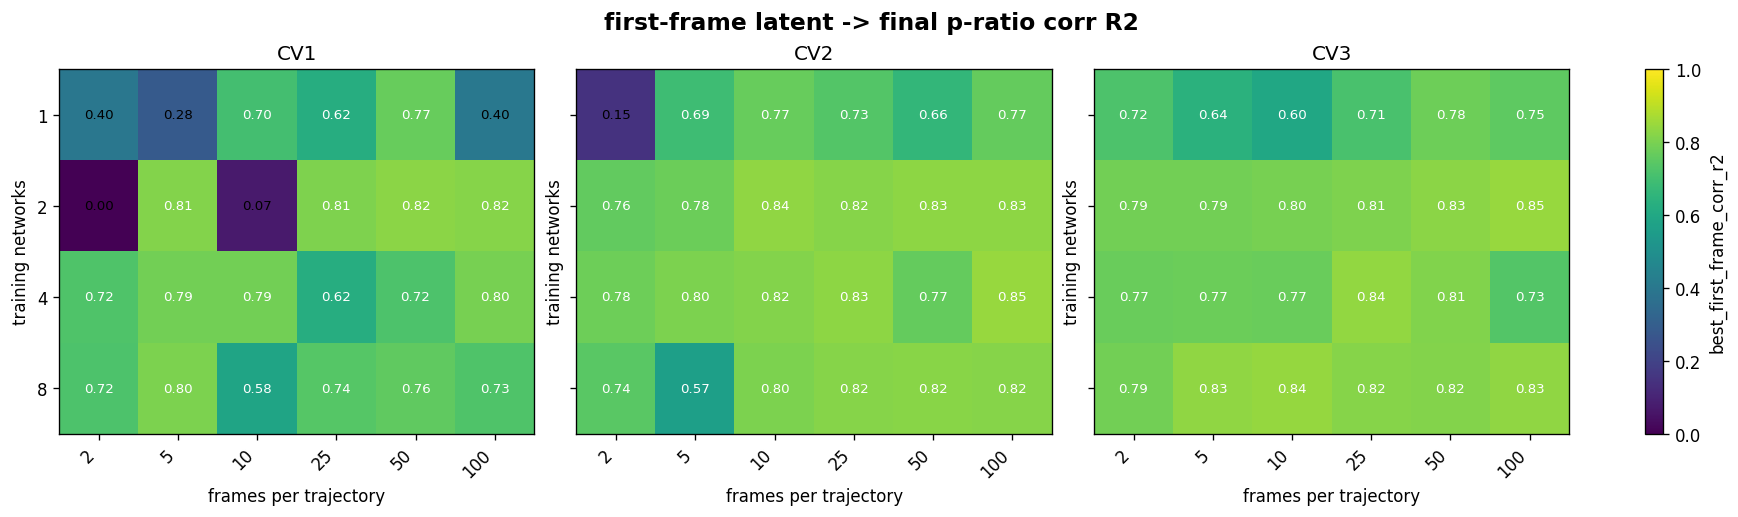

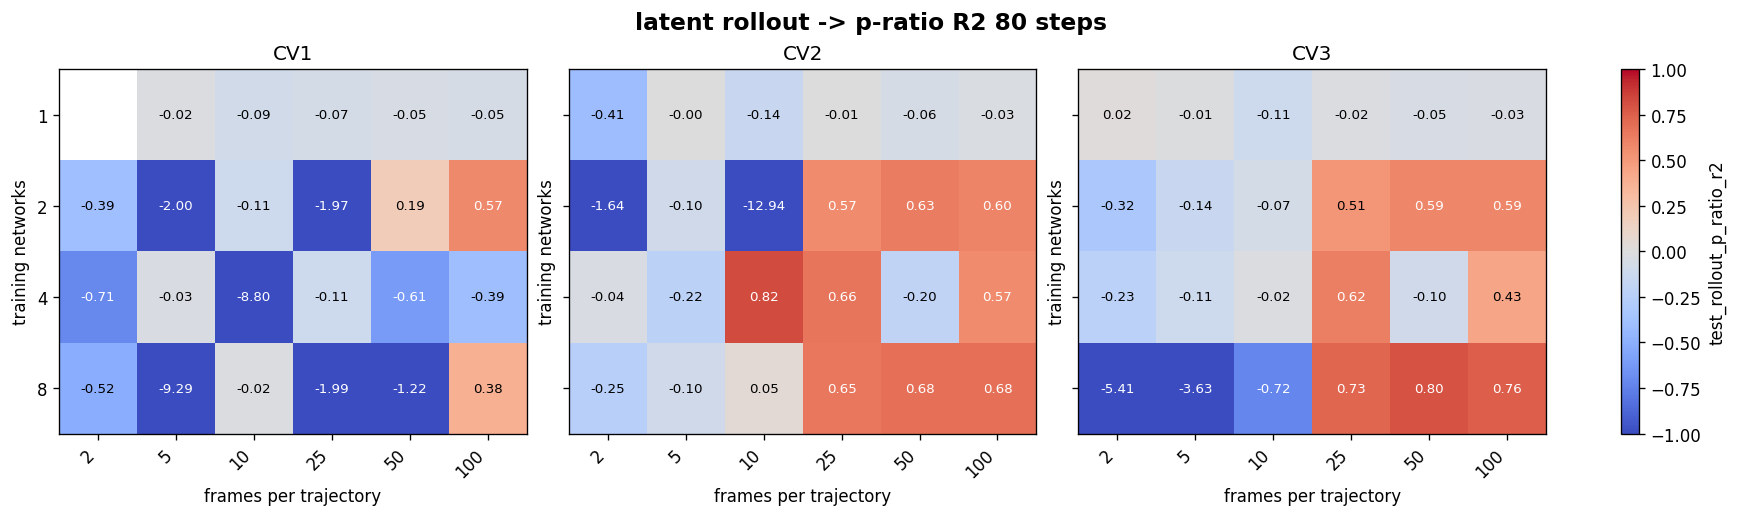

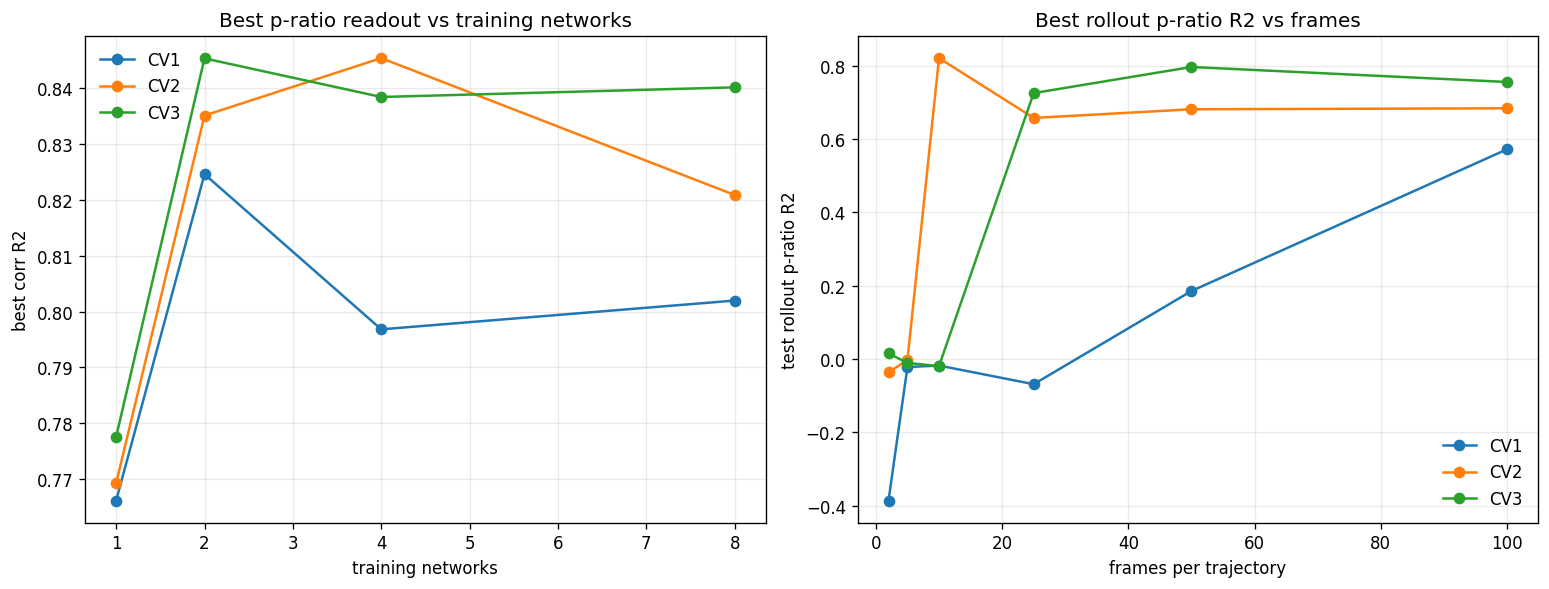

In [54]:
if sweep_summary_df.empty:
    print('Run the sweep cell first.')
else:
    metric_specs = [
        ('best_first_frame_corr_r2', 'first-frame latent -> final p-ratio corr R2'),
        ('test_rollout_p_ratio_r2', f'latent rollout -> p-ratio R2 {cfg["summary_rollout_step"]} steps'),
    ]
    for metric, title in metric_specs:
        fig, axes = plt.subplots(1, len(latent_dims), figsize=(4.8 * len(latent_dims), 4.2), constrained_layout=True, sharey=True)
        axes = np.atleast_1d(axes)
        for ax, latent_dim in zip(axes, latent_dims):
            group = sweep_summary_df[sweep_summary_df['latent_dim'].eq(latent_dim)]
            heat = group.pivot_table(index='train_networks', columns='train_frames_per_network', values=metric)
            heat = heat.reindex(index=train_counts, columns=train_frame_counts)
            im = ax.imshow(heat.to_numpy(dtype=float), vmin=-1 if 'rollout' in metric else 0, vmax=1, cmap='viridis' if 'corr' in metric else 'coolwarm', aspect='auto')
            ax.set_title(f'CV{latent_dim}')
            ax.set_xlabel('frames per trajectory')
            ax.set_xticks(range(len(heat.columns)))
            ax.set_xticklabels(heat.columns, rotation=45, ha='right')
            ax.set_yticks(range(len(heat.index)))
            ax.set_yticklabels(heat.index)
            ax.set_ylabel('training networks')
            for y in range(heat.shape[0]):
                for x in range(heat.shape[1]):
                    val = heat.iloc[y, x]
                    if np.isfinite(val):
                        ax.text(x, y, f'{val:.2f}', ha='center', va='center', fontsize=8, color='white' if abs(val) > 0.55 else 'black')
        fig.colorbar(im, ax=axes.tolist(), label=metric)
        fig.suptitle(title, fontsize=14, fontweight='bold')
        plt.show()

    fig, axes = plt.subplots(1, 2, figsize=(12.8, 4.8), constrained_layout=True)
    for latent_dim, group in sweep_summary_df.groupby('latent_dim', sort=True):
        best_by_networks = group.groupby('train_networks', as_index=False)['best_first_frame_corr_r2'].max()
        axes[0].plot(best_by_networks['train_networks'], best_by_networks['best_first_frame_corr_r2'], marker='o', label=f'CV{latent_dim}')
        best_by_frames = group.groupby('train_frames_per_network', as_index=False)['test_rollout_p_ratio_r2'].max()
        axes[1].plot(best_by_frames['train_frames_per_network'], best_by_frames['test_rollout_p_ratio_r2'], marker='o', label=f'CV{latent_dim}')
    axes[0].set_title('Best p-ratio readout vs training networks')
    axes[0].set_xlabel('training networks')
    axes[0].set_ylabel('best corr R2')
    axes[1].set_title('Best rollout p-ratio R2 vs frames')
    axes[1].set_xlabel('frames per trajectory')
    axes[1].set_ylabel('test rollout p-ratio R2')
    for ax in axes:
        ax.grid(alpha=0.25)
        ax.legend(frameon=False)
    plt.show()


## Exports


In [55]:
sweep_export_dir = run_dir / 'exports'
sweep_export_dir.mkdir(parents=True, exist_ok=True)
export_tables = {
    'sweep_summary': globals().get('sweep_summary_df'),
    'sweep_readout': globals().get('sweep_readout_df'),
    'sweep_first_frame_latents': globals().get('sweep_first_frame_latent_df'),
    'sweep_rollout_stats': globals().get('sweep_rollout_stats_df'),
    'sweep_ae_history': globals().get('sweep_ae_history_df'),
    'sweep_dyn_history': globals().get('sweep_dyn_history_df'),
}
manifest = []
for name, table in export_tables.items():
    if isinstance(table, pd.DataFrame) and not table.empty:
        path = sweep_export_dir / f'{name}.csv'
        table.to_csv(path, index=False)
        manifest.append({'name': name, 'rows': len(table), 'cols': len(table.columns), 'path': str(path)})
    else:
        manifest.append({'name': name, 'rows': 0, 'cols': 0, 'path': ''})
sweep_manifest_df = pd.DataFrame(manifest)
sweep_manifest_df.to_csv(sweep_export_dir / 'manifest.csv', index=False)
display(sweep_manifest_df)
print(f'Wrote sweep exports to {sweep_export_dir}')


,name,rows,cols,path
0,sweep_summary,72,13,results/latent_space_capacity_sweep/exports/sw...
1,sweep_readout,246,9,results/latent_space_capacity_sweep/exports/sw...
2,sweep_first_frame_latents,5544,10,results/latent_space_capacity_sweep/exports/sw...
3,sweep_rollout_stats,72,14,results/latent_space_capacity_sweep/exports/sw...
4,sweep_ae_history,1617,9,results/latent_space_capacity_sweep/exports/sw...
5,sweep_dyn_history,1542,10,results/latent_space_capacity_sweep/exports/sw...


Wrote sweep exports to results/latent_space_capacity_sweep/exports
